In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [2]:
HD1_gene_cell = ad.read_mtx('data/pbmcs_multiple_sample/HD1/Gene_Cell.mtx')
HD1_adata = sc.AnnData(HD1_gene_cell.transpose())
HD1_gene_names = pd.read_csv('data/pbmcs_multiple_sample/HD1/Gene_names.tsv', sep='\t', header=None)
HD1_cell_names = pd.read_csv('data/pbmcs_multiple_sample/HD1/Cell_names.tsv', sep='\t', header=None)

HD1_adata.var_names = HD1_gene_names[0]
HD1_adata.obs_names = HD1_cell_names[0]
HD1_adata

AnnData object with n_obs × n_vars = 7565 × 22336

In [3]:
HD2_gene_cell = ad.read_mtx('data/pbmcs_multiple_sample/HD2/Gene_Cell.mtx')
HD2_adata = sc.AnnData(HD2_gene_cell.transpose())
HD2_gene_names = pd.read_csv('data/pbmcs_multiple_sample/HD2/Gene_names.tsv', sep='\t', header=None)
HD2_cell_names = pd.read_csv('data/pbmcs_multiple_sample/HD2/Cell_names.tsv', sep='\t', header=None)

HD2_adata.var_names = HD2_gene_names[0]
HD2_adata.obs_names = HD2_cell_names[0]
HD2_adata

AnnData object with n_obs × n_vars = 11952 × 22336

In [4]:
HD1_adata.obs['batch'] = 'batch1'
HD2_adata.obs['batch'] = 'batch2'
adata = ad.concat([HD1_adata, HD2_adata], join='outer', label='batch', keys=['batch1', 'batch2'])
adata

AnnData object with n_obs × n_vars = 19517 × 22336
    obs: 'batch'

In [5]:
RNA_matrix = adata.X.transpose()

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_num, gene_num

(19517, 22336)

In [6]:
initial_pre = initial_clustering(RNA_matrix)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix)
n_batch = len(indices)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
Partitioning the data into batches. Please wait...


Processing Batches: 100%|██████████| 651/651 [31:53<00:00,  2.94s/it]


In [7]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
node_model = NodeDimensionReduction(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                                    n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                                    num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

The training process for the NodeDimensionReduction model has started. Please wait.


100%|██████████| 100/100 [6:33:54<00:00, 236.34s/it] 

The training for the NodeDimensionReduction model has been completed.


In [8]:
ScFormer_model = ScFormer(gnn=gnn, h=h, labsm=0.1, n_hid=104, n_batch=n_batch, device=device, lr=0.0005, wd=0.1,
                          num_epochs=50)
ScFormer_gnn, _, _, _ = ScFormer_model.train_model(indices=indices, RNA_matrix=RNA_matrix, ini_p1=ini_p1)

The training process for the scformer model has started. Please wait.
Forward pass started.


Epochs: 100%|██████████| 50/50 [3:16:19<00:00, 235.60s/it]  

The training for the scformer model has been completed.
The training for the scformer model has been completed.


In [9]:
ScFormer_result = ScFormer_pred(RNA_matrix, gnn=ScFormer_gnn, indices=indices,
                                nodes_id=Node_Ids, device=device)
# Save numpy arrays to files
output_file = 'data/pbmcs_multiple_sample/output/HD1_HD2'
os.makedirs(output_file, exist_ok=True)
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

Prediction Batches: 100%|██████████| 651/651 [03:48<00:00,  2.85it/s]


In [10]:
Node_Ids = np.load("data/pbmcs_multiple_sample/output/HD1_HD2/node_ids.npy")

cell_emb = np.load('data/pbmcs_multiple_sample/output/HD1_HD2/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
4891,-1.213419,-0.768626,-1.293056,-1.694276,-1.683342,4.794806,-1.366330,-1.019889,-1.509253,-1.308489,...,-2.191843,-2.183537,-2.190421,-2.191787,-2.192322,-2.192152,-2.192546,-2.193076,-2.192876,-2.189886
14946,-1.003071,-1.157733,-1.129394,-1.219281,-1.185655,-1.079888,-1.250787,-1.117186,-1.211961,-1.188056,...,-2.191885,-2.190381,-2.189100,-2.191758,-2.189155,-2.192741,-2.191779,-2.191453,-2.191713,-2.191492
12331,4.687487,-1.453062,-1.794242,-1.309655,-1.931974,-1.867226,-1.641499,-1.767686,-1.714889,-1.229219,...,-2.191561,-2.192109,-2.188870,-2.191837,-2.193552,-2.190309,-2.195685,-2.196002,-2.195467,-2.189785
17132,-1.416956,-1.643062,-0.831077,-1.687762,-1.157159,-1.380821,-1.433827,-1.020967,-1.276533,-1.494128,...,-2.191814,-2.189024,-2.191136,-2.191802,-2.192097,-2.191200,-2.193311,-2.192970,-2.192591,-2.193451
16510,-1.317069,4.802557,-1.466004,-1.150085,-1.784029,-1.418025,-0.960206,-1.108550,-1.544892,-1.292765,...,-2.191643,-2.184272,-2.196746,-2.191804,-2.192579,-2.190825,-2.192345,-2.188990,-2.194021,-2.193404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3965,-0.673419,5.005357,-1.200923,-1.265454,-1.406577,-1.317350,-1.258240,-1.079956,-1.559497,-1.117188,...,-2.191657,-2.189205,-2.196268,-2.191875,-2.188379,-2.190579,-2.193425,-2.188815,-2.193924,-2.193592
12834,-1.179591,-0.817602,-1.374964,-1.647416,-1.338748,4.712235,-1.566609,0.138843,-1.324390,-0.359167,...,-2.191761,-2.185034,-2.190000,-2.191769,-2.191120,-2.192707,-2.192940,-2.190211,-2.190911,-2.190768
8720,4.962691,-0.999974,-1.504519,-1.224730,-1.574145,-2.071683,-1.578197,-1.459412,-1.348749,-1.025811,...,-2.191885,-2.196773,-2.188081,-2.191831,-2.189221,-2.191096,-2.195068,-2.194309,-2.193958,-2.189158
2167,-1.185936,-0.852534,-1.409687,4.794485,-1.779418,-1.726223,-1.548403,-1.321856,-1.241492,-0.941712,...,-2.191723,-2.192766,-2.190401,-2.191758,-2.193073,-2.191162,-2.192452,-2.193677,-2.192726,-2.192488


In [11]:
cell_emb_sorted = cell_emb_.sort_index()
cell_emb_sorted

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,-1.346295,-1.211250,-1.046980,-1.224009,4.905132,-1.333077,-1.369554,-1.195978,-1.079142,-1.349718,...,-2.191711,-2.194115,-2.189622,-2.191653,-2.192326,-2.190886,-2.189816,-2.190712,-2.192392,-2.189837
1,-1.185829,-1.307667,-1.142139,-0.832078,4.934839,-0.991499,-1.066944,-0.991983,-1.089121,-0.954175,...,-2.191748,-2.188161,-2.189165,-2.191663,-2.191497,-2.192441,-2.189467,-2.190234,-2.191419,-2.191725
2,-1.019567,-0.905255,-1.431097,-1.413967,4.956335,-1.199127,-1.229355,-1.043226,-1.209524,-0.936289,...,-2.191746,-2.189603,-2.189947,-2.191766,-2.191559,-2.192270,-2.191484,-2.191129,-2.191606,-2.190250
3,-0.859277,-1.606282,-1.323415,-1.355673,4.835562,-1.035464,-1.213027,-1.205714,-1.195955,-1.628908,...,-2.191835,-2.188334,-2.193232,-2.191679,-2.190515,-2.192344,-2.191530,-2.194216,-2.190879,-2.190252
4,-1.142727,-0.847506,-1.216686,4.926331,-1.379855,-1.457719,-1.309077,-1.246290,-1.223117,-1.285589,...,-2.191694,-2.190187,-2.192526,-2.191768,-2.189921,-2.191316,-2.189764,-2.192481,-2.193037,-2.192418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19512,4.878757,-1.557200,-1.746030,-1.460502,-1.971316,-1.957597,-1.389878,-1.576177,-1.235522,-0.996738,...,-2.191692,-2.190997,-2.192695,-2.191796,-2.190113,-2.191390,-2.194164,-2.191688,-2.192501,-2.193626
19513,4.713796,-0.886574,-1.681129,-0.042760,-2.146204,-1.955851,-1.509722,-1.635268,-1.793146,-1.118263,...,-2.191679,-2.189693,-2.191606,-2.191824,-2.192578,-2.191924,-2.194542,-2.193362,-2.193091,-2.192447
19514,-1.335962,4.642075,-1.390125,-1.381365,-2.452079,-1.091050,-1.265820,-1.104266,-1.194040,-0.959526,...,-2.191627,-2.174134,-2.196870,-2.191841,-2.192383,-2.190064,-2.194564,-2.188708,-2.194180,-2.187734
19515,-0.343990,-1.716619,0.554858,-2.155173,-2.024984,-1.788397,-1.508237,-0.034167,-2.376367,-0.815725,...,-2.191697,-2.191004,-2.186646,-2.191589,-2.190691,-2.190369,-2.190116,-2.191489,-2.190544,-2.193049


In [12]:
adata.obsm['cell_emb'] = cell_emb_sorted.values

In [13]:
pred = np.load('data/pbmcs_multiple_sample/output/HD1_HD2/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
pred_sorted

,0
0,4
1,4
2,4
3,4
4,3
...,...
19512,0
19513,0
19514,1
19515,16


In [14]:
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

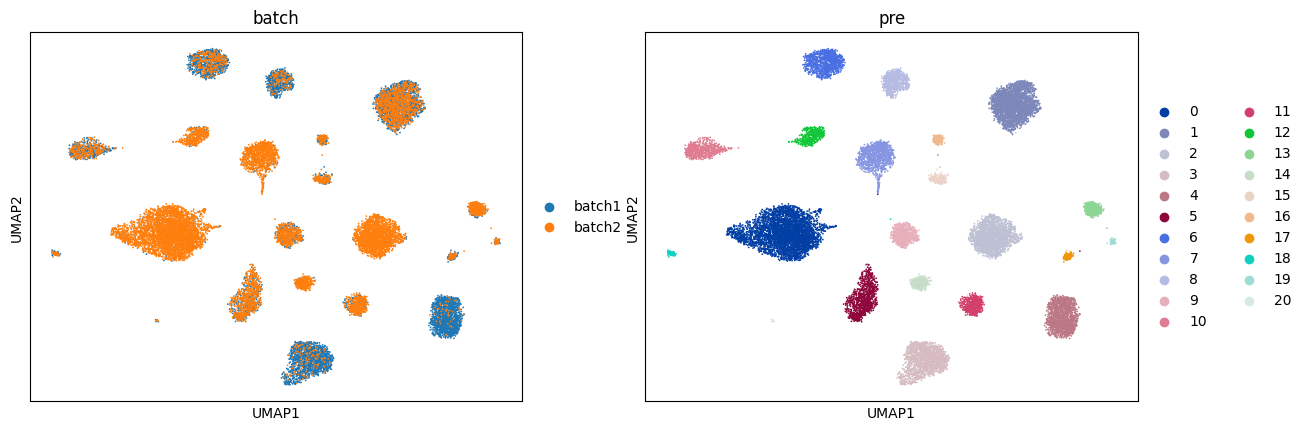

In [15]:
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['batch', 'pre'], show=True)

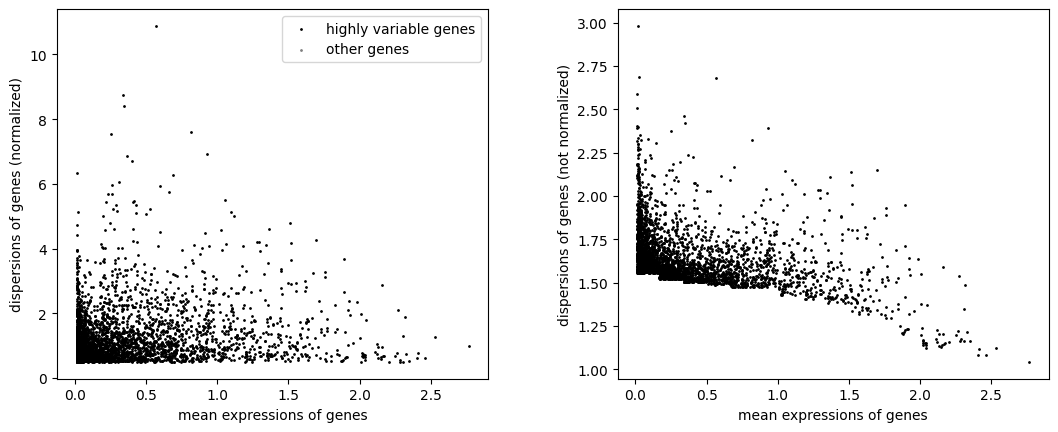

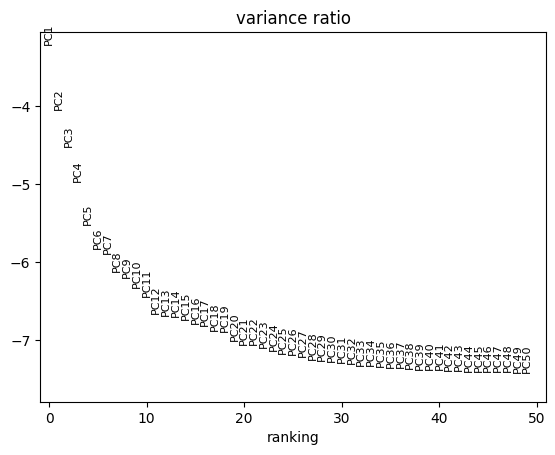

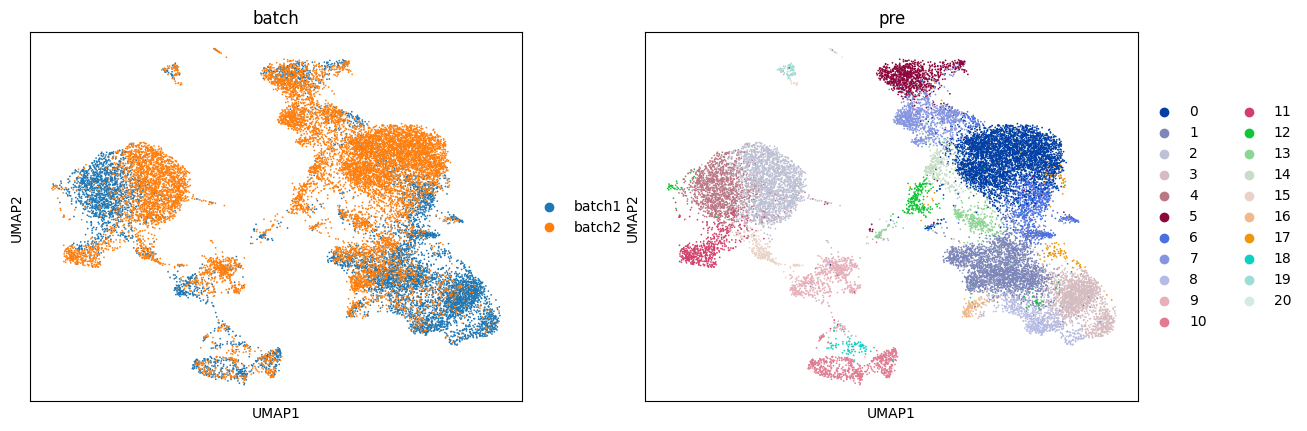

In [16]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# adata.var['mt'] = adata.var_names.str.startswith('MT-')
# sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mt'], jitter=0.4)

# 标准化和识别高度变异基因
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var['highly_variable']]
sc.pl.highly_variable_genes(adata)

# PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

# 邻接图
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color=['batch','pre'])